In [22]:
import numpy as np
import scipy.sparse as sp
import Hamiltonian as ham
import Evolution_sim as evol
import PauliStrings as ps
import transpile as tr
import matplotlib.pyplot as plt
from qiskit.providers.fake_provider import GenericBackendV2

import importlib
evol = importlib.reload(evol)
ham = importlib.reload(ham)
tr = importlib.reload(tr)

In [4]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]
def energy_variance(psi, H):
    '''
    Calculate the energy variance for a given state and Hamiltonian.
    
    Parameters:
    psi (scipy.sparse.csc_matrix): The quantum state as a sparse column vector
    H (scipy.sparse.csc_matrix): The Hamiltonian operator
    
    Returns:
    float: The energy variance <H²> - <H>²
    '''
    exp_H2 = float(np.real((psi.conj().T @ (H@H) @ psi).toarray()[0,0]))
    exp_H = float(np.real((psi.conj().T @ H @ psi).toarray()[0,0]))
    return exp_H2 - exp_H**2

In [5]:
n_qubits = 5
D=2
T=2
J=0.5
h=1
dt=0.1
N=50
tmax=dt*N
t=0 + np.arange(0, N+1) *dt
H,H_trot=ham.TFIM(J,h,n_qubits,T=T)
psi0np=np.zeros((2**n_qubits,1),dtype=complex)
psi0np[0]=1
psi_0=sp.csc_matrix(psi0np/np.linalg.norm(psi0np))

In [11]:

EH,VH = np.linalg.eigh(H.todense())
psigs=VH[:,0]

EQ,psi_QITE,a = evol.QITE(n_qubits,H,H_trot,D,psi_0,N,dt,vervose=False)
Eadap,psi_adap,indx,times,a_adap = evol.ACQ(n_qubits,H,H_trot,D,psi_0,N,dt)
num_paulis,PD,fail = ps.real(H_trot,D,n_qubits,PDstr=True)

Energy doubly increased at step 10
Using Real Pauli Strings
Computing U at step 0
Computing U at step 8
Computing U at step 10
Energy doubly increased, stopping criteria activated at step 11


In [12]:
#Fidelities
F_QITE=[]
for i in range(len(EQ)):
    F_QITE.append(fidelity_pure(psigs,psi_QITE[:,i].todense()))

F_adap=[]
for i in range(len(Eadap)):
    F_adap.append(fidelity_pure(psigs,psi_adap[:,i].todense()))

#Energy Variance
varE_QITE = [energy_variance(psi_QITE[:,i], H) for i in range(len(EQ))]
varE_adap = [energy_variance(psi_adap[:,i], H) for i in range(len(Eadap))]

In [13]:
backend1 = GenericBackendV2(num_qubits=n_qubits,basis_gates=['u3','cx'])

In [23]:
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity

# Plot error and metrics for each optimization level
opt_levels = [1,3]  # optimization levels to compare

# steps
steps_qite = len(a)
steps_adap = len(a_adap)

# Prepare containers mapping optimization level -> time series lists
error_qite = {opt: [] for opt in opt_levels}
energy_qite_transpiled = {opt: [] for opt in opt_levels}
fidelity_qite_transpiled = {opt: [] for opt in opt_levels}
variance_qite_transpiled = {opt: [] for opt in opt_levels}

error_adap = {opt: [] for opt in opt_levels}
energy_adap_transpiled = {opt: [] for opt in opt_levels}
fidelity_adap_transpiled = {opt: [] for opt in opt_levels}
variance_adap_transpiled = {opt: [] for opt in opt_levels}

# Dictionaries to keep the final transpiled circuit (full evolution) per opt level
tr_qc_v_by_opt = {}
tr_qc_u_by_opt = {}

# QITE-series: run transpilation across steps for each optimization level
for opt in opt_levels:
    print(f"Transpiling QITE series with optimization level {opt}")
    for step in range(steps_qite + 1):  # include initial state (step=0)
        tr_qc_v, _, v_error = tr.transpile_circuit_qite(n_qubits,D,T,PD,a, dt, step, backend=backend1, op_level=opt,PEvolution=False)
        # save final (full-evolution) transpiled circuit for this opt level
        if step == steps_qite:
            tr_qc_v_by_opt[opt] = tr_qc_v
        error_qite[opt].append(v_error)
        final_state = Statevector(psi0np).evolve(tr_qc_v)
        energy = np.real((final_state.data.conj().T @ H.todense() @ final_state.data)[0, 0])
        energy_qite_transpiled[opt].append(energy)
        fidelity = state_fidelity(final_state, psigs)
        fidelity_qite_transpiled[opt].append(fidelity)
        variance = energy_variance(sp.csc_matrix(final_state.data).T, H)
        variance_qite_transpiled[opt].append(variance)

# AdaQITE-series: same as above but using the adaptive circuits
for opt in opt_levels:
    print(f"Transpiling AdaQITE series with optimization level {opt}")
    for step in range(steps_adap + 1):
        tr_qc_u, _, u_error = tr.transpile_circuit_qite_adap(n_qubits,D,T,PD,a_adap, times, step, backend=backend1, op_level=opt,PEvolution=False)
        # save final (full-evolution) transpiled circuit for this opt level
        if step == steps_adap:
            tr_qc_u_by_opt[opt] = tr_qc_u
        error_adap[opt].append(u_error)
        final_state = Statevector(psi0np).evolve(tr_qc_u)
        energy = np.real((final_state.data.conj().T @ H.todense() @ final_state.data)[0, 0])
        energy_adap_transpiled[opt].append(energy)
        fidelity = state_fidelity(final_state, psigs)
        fidelity_adap_transpiled[opt].append(fidelity)
        variance = energy_variance(sp.csc_matrix(final_state.data).T, H)
        variance_adap_transpiled[opt].append(variance)

print('Done transpiling and collecting metrics for opt levels:', opt_levels)


Transpiling QITE series with optimization level 1
Transpiling QITE series with optimization level 3
Transpiling AdaQITE series with optimization level 1
Transpiling AdaQITE series with optimization level 3
Done transpiling and collecting metrics for opt levels: [1, 3]


Text(0.5, 1.02, 'QITE: Analytic vs Transpiled (opt levels [1, 3]) N5 D2 T2 J0.5 h1')

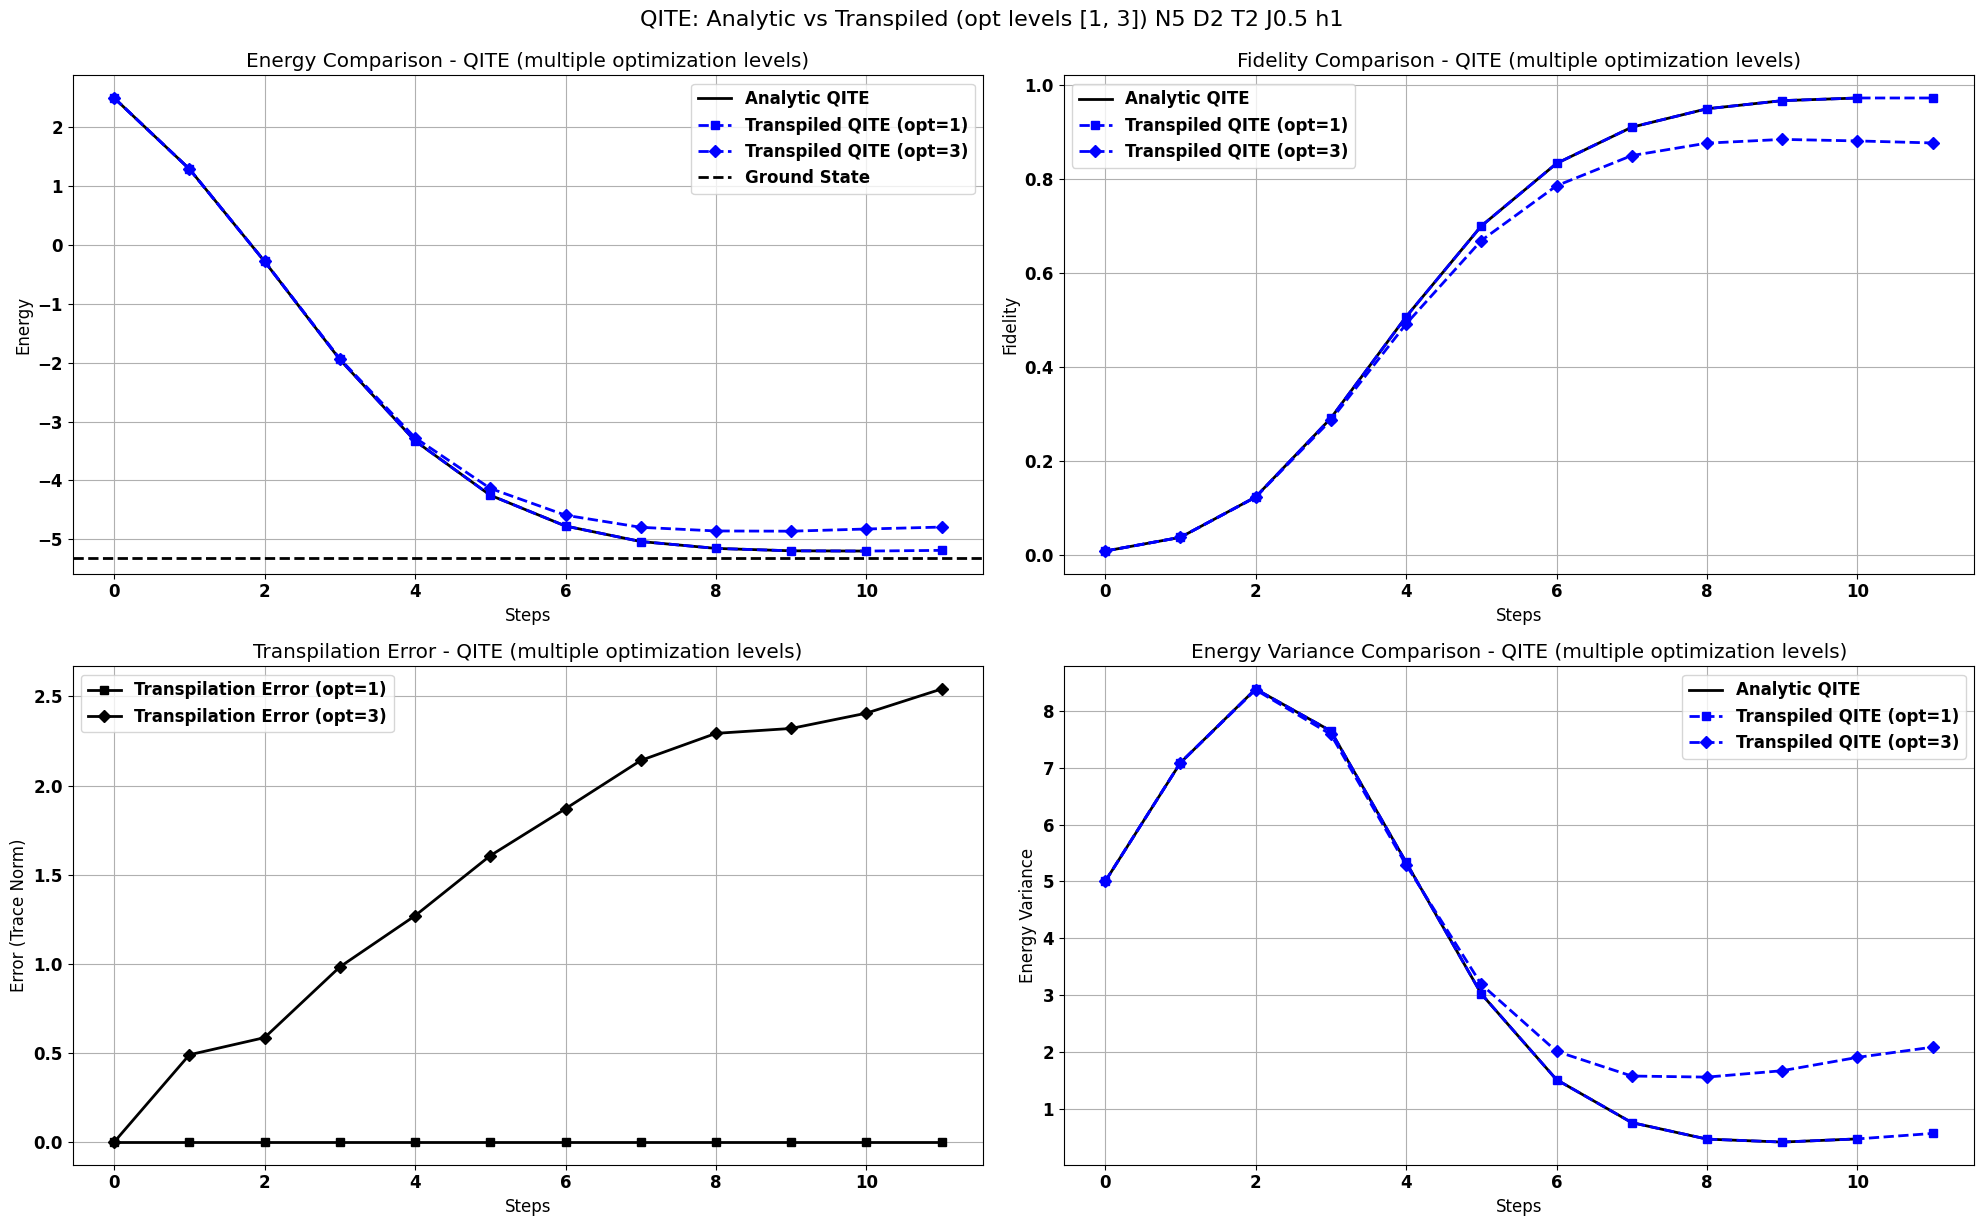

In [31]:
# Create figure for QITE comparison across optimization levels
plt.figure(figsize=(20, 12))
font = {'weight': 'bold', 'size': 12}
plt.rc('font', **font)

# define markers per optimization level (customize as you like)
markers = {0: 'o',1:'s',2:'^',3:'D'}

# Energy subplot
plt.subplot(2, 2, 1)
plt.plot(range(steps_qite), EQ, '-k', linewidth=2, label='Analytic QITE')
for opt in opt_levels:
    m = markers[opt]
    plt.plot(range(steps_qite + 1), energy_qite_transpiled[opt],'--b', linewidth=2, marker=m, label=f'Transpiled QITE (opt={opt})')
plt.axhline(y=EH[0], color='k', linestyle='--', linewidth=2, label='Ground State')
plt.xlabel("Steps")
plt.ylabel("Energy")
plt.title("Energy Comparison - QITE (multiple optimization levels)")
plt.grid(True)
plt.legend()

# Fidelity subplot
plt.subplot(2, 2, 2)
plt.plot(range(steps_qite), F_QITE, '-k', linewidth=2, label='Analytic QITE')
for opt in opt_levels:
    m = markers[opt]
    plt.plot(range(steps_qite + 1), fidelity_qite_transpiled[opt], '--b', linewidth=2, marker=m, label=f'Transpiled QITE (opt={opt})')
plt.xlabel("Steps")
plt.ylabel("Fidelity")
plt.title("Fidelity Comparison - QITE (multiple optimization levels)")
plt.grid(True)
plt.legend()

# Error subplot
plt.subplot(2, 2, 3)
for opt in opt_levels:
    m = markers[opt]
    plt.plot(range(steps_qite + 1), error_qite[opt],'-k',linewidth=2, marker=m, label=f'Transpilation Error (opt={opt})')
plt.xlabel("Steps")
plt.ylabel("Error (Trace Norm)")
plt.title("Transpilation Error - QITE (multiple optimization levels)")
plt.grid(True)
plt.legend()

# Variance subplot
plt.subplot(2, 2, 4)
plt.plot(range(steps_qite), varE_QITE[:len(variance_qite_transpiled[opt_levels[0]])], '-k', linewidth=2, label='Analytic QITE')
for opt in opt_levels:
    m = markers.get(opt, 'o')
    plt.plot(range(steps_qite + 1), variance_qite_transpiled[opt], '--b', linewidth=2, marker=m, label=f'Transpiled QITE (opt={opt})')
plt.xlabel("Steps")
plt.ylabel("Energy Variance")
plt.title("Energy Variance Comparison - QITE (multiple optimization levels)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.suptitle(f"QITE: Analytic vs Transpiled (opt levels {opt_levels}) N{n_qubits} D{D} T{T} J{J} h{h}", y=1.02, fontsize=16)
#plt.savefig(f"QITE_analytic_vs_transpiled_N{n_qubits}D{D}T{T}J{J}H{h}DEVGEN.png", dpi=300, bbox_inches='tight')


Text(0.5, 1.02, 'AdaQITE: Analytic vs Transpiled (opt levels [1, 3]) N5 D2 T2 J0.5 h1')

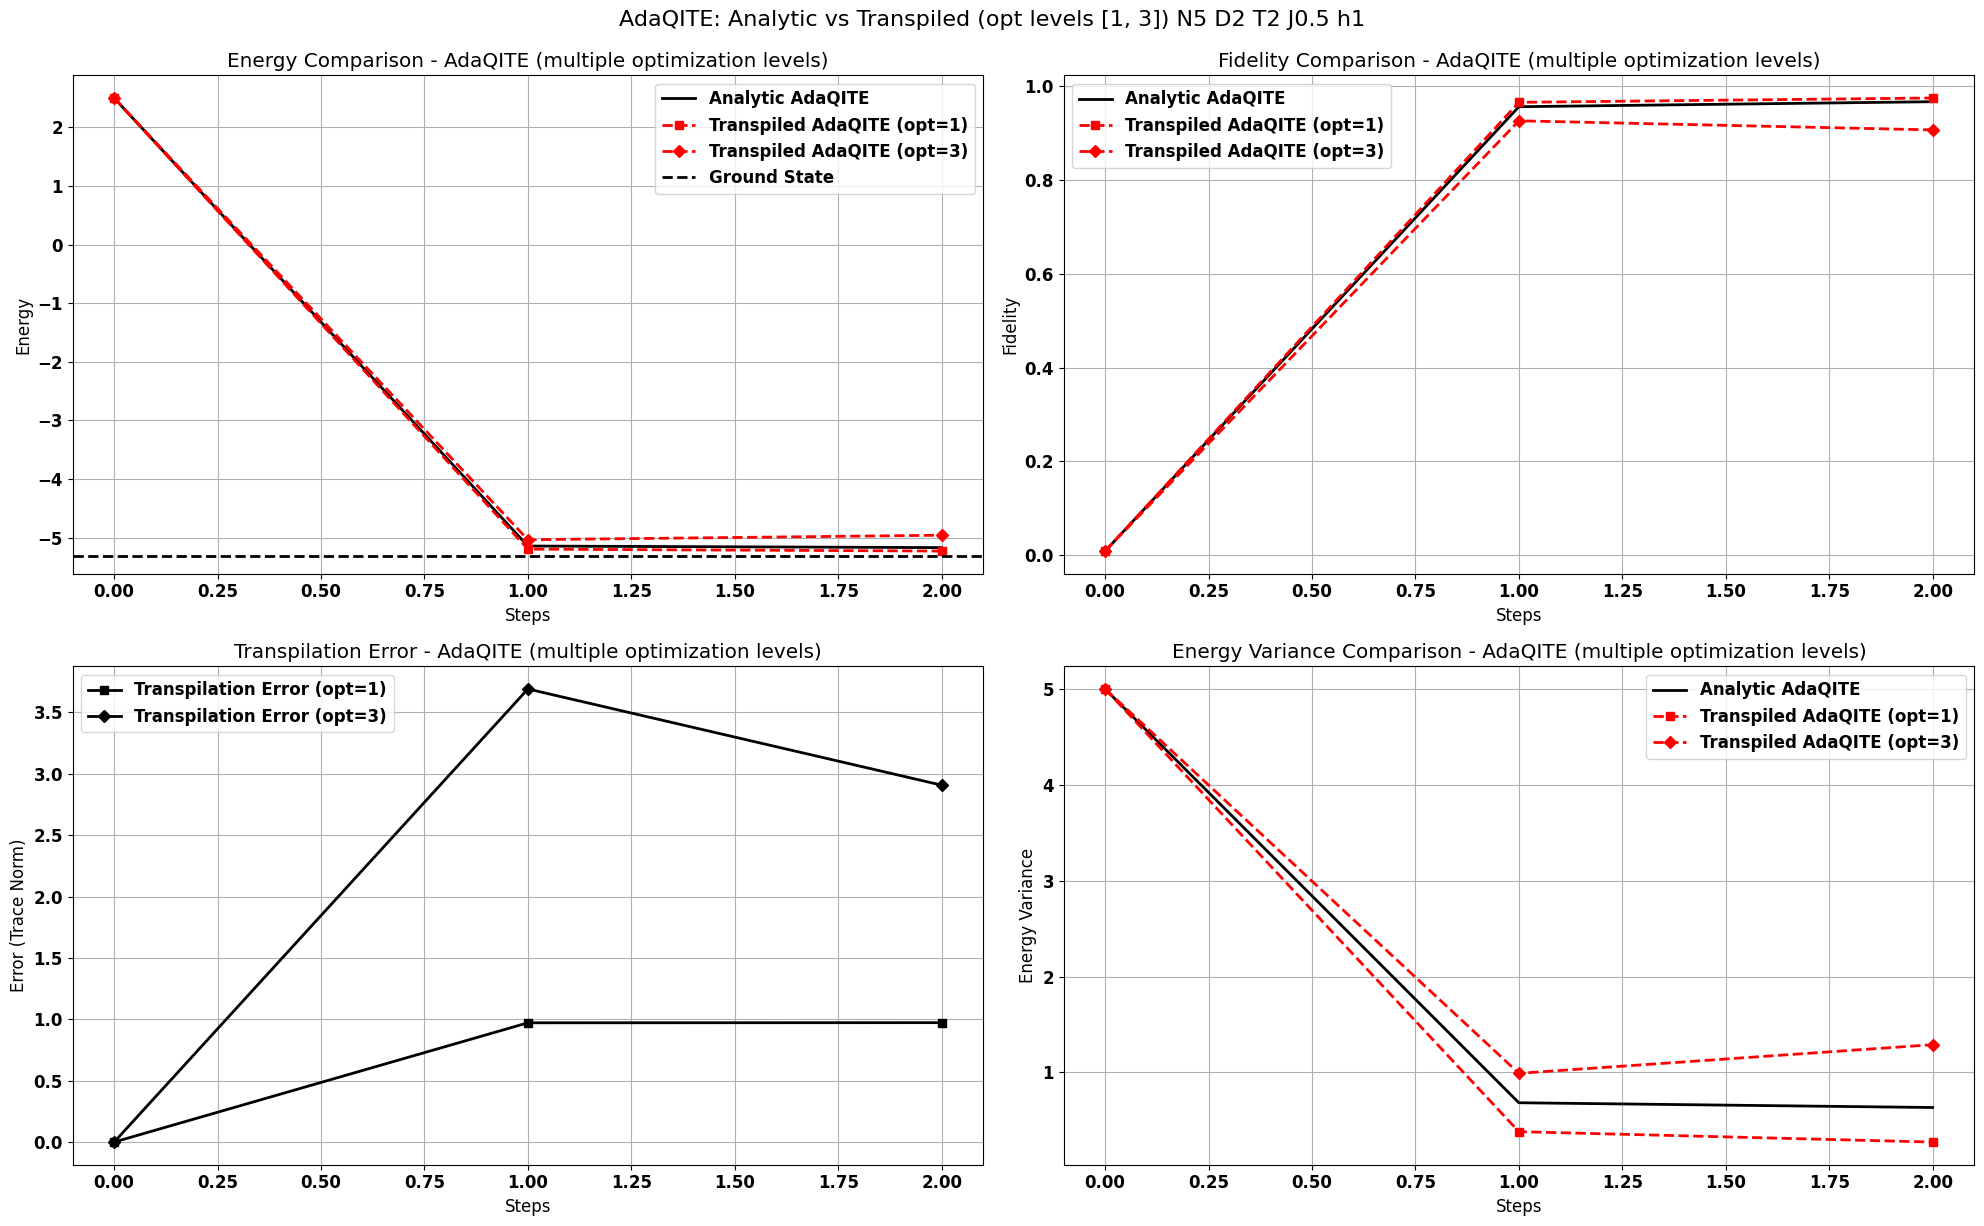

In [25]:
# Create figure for AdaQITE comparison across optimization levels
plt.figure(figsize=(20, 12))
font = {'weight': 'bold', 'size': 12}
plt.rc('font', **font)

# define markers per optimization level (customize as you like)
markers = {0: 'o',1:'s',2:'^',3:'D'}

# Energy subplot
plt.subplot(2, 2, 1)
plt.plot(range(steps_adap + 1), Eadap[indx], '-k', linewidth=2, label='Analytic AdaQITE')
for opt in opt_levels:
    m = markers[opt]
    plt.plot(range(steps_adap + 1), energy_adap_transpiled[opt], '--r', linewidth=2, marker=m, label=f'Transpiled AdaQITE (opt={opt})')
plt.axhline(y=EH[0], color='k', linestyle='--', linewidth=2, label='Ground State')
plt.xlabel("Steps")
plt.ylabel("Energy")
plt.title("Energy Comparison - AdaQITE (multiple optimization levels)")
plt.grid(True)
plt.legend()

# Fidelity subplot
plt.subplot(2, 2, 2)
plt.plot(range(steps_adap + 1), np.array(F_adap)[indx], '-k', linewidth=2, label='Analytic AdaQITE')
for opt in opt_levels:
    m = markers[opt]
    plt.plot(range(steps_adap + 1), fidelity_adap_transpiled[opt],'--r', linewidth=2, marker=m, label=f'Transpiled AdaQITE (opt={opt})')
plt.xlabel("Steps")
plt.ylabel("Fidelity")
plt.title("Fidelity Comparison - AdaQITE (multiple optimization levels)")
plt.grid(True)
plt.legend()

# Error subplot
plt.subplot(2, 2, 3)
for opt in opt_levels:
    m = markers[opt]
    plt.plot(range(steps_adap + 1), error_adap[opt],'-k',linewidth=2, marker=m, label=f'Transpilation Error (opt={opt})')
plt.xlabel("Steps")
plt.ylabel("Error (Trace Norm)")
plt.title("Transpilation Error - AdaQITE (multiple optimization levels)")
plt.grid(True)
plt.legend()

# Variance subplot
plt.subplot(2, 2, 4)
plt.plot(range(steps_adap + 1), np.array(varE_adap)[indx], '-k', linewidth=2, label='Analytic AdaQITE')
for opt in opt_levels:
    m = markers[opt]
    plt.plot(range(steps_adap + 1), variance_adap_transpiled[opt],'--r', linewidth=2, marker=m, label=f'Transpiled AdaQITE (opt={opt})')
plt.xlabel("Steps")
plt.ylabel("Energy Variance")
plt.title("Energy Variance Comparison - AdaQITE (multiple optimization levels)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.suptitle(f"AdaQITE: Analytic vs Transpiled (opt levels {opt_levels}) N{n_qubits} D{D} T{T} J{J} h{h}", y=1.02, fontsize=16)
#plt.savefig(f"AdaQITE_analytic_vs_transpiled_N{n_qubits}D{D}T{T}J{J}H{h}DEVGEN.png", dpi=300, bbox_inches='tight')



In [35]:
# Compute transpiled circuits for first step only across D=[2,4] and opt_levels=[1,3]

# Parameters
n_qubits = 5
T=2
J=0.5
h=1
dt=0.1
N=50
H,H_trot=ham.TFIM(J,h,n_qubits,T=T)
psi0np=np.zeros((2**n_qubits,1),dtype=complex)
psi0np[0]=1
psi_0=sp.csc_matrix(psi0np/np.linalg.norm(psi0np))
D_values = [2, 4]
opt_levels = [1, 3]
backend1 = GenericBackendV2(num_qubits=n_qubits,basis_gates=['u3','cx'])

# Dictionary to store gate counts: {D: {opt: {'QITE': {'Ham':..., 'Pauli':...}, 'AdaQITE': {...}}}}
gate_counts = {}

# Loop over D values
for D in D_values:
    print(f"\n=== Processing D={D} ===")
    
    # Compute QITE and adaptive QITE
    EQ_temp, psi_QITE_temp, a_temp = evol.QITE(n_qubits, H, H_trot, D, psi_0, N, dt, vervose=False)
    Eadap_temp, psi_adap_temp, indU_temp, times_temp, a_adap_temp = evol.ACQ(n_qubits, H, H_trot, D, psi_0, N, dt)
    
    # Get Pauli decomposition
    num_paulis_temp, PD_temp, fail_temp = ps.real(H_trot, D, n_qubits, PDstr=True)
    
    gate_counts[D] = {}
    
    # Loop over optimization levels
    for opt in opt_levels:
        print(f"  Optimization level: {opt}")
        
        # Transpile QITE circuit (first step only) using HamiltonianGate
        tr_qc_qite_h, _, _ = tr.transpile_circuit_qite(n_qubits,D,T,PD_temp, a_temp, dt, 1, backend=backend1, op_level=opt, PEvolution=False)
        gates_qite_h = sum(tr_qc_qite_h.count_ops().values())
        # Transpile QITE circuit (first step only) using PauliEvolutionGate
        tr_qc_qite_p, _, _ = tr.transpile_circuit_qite(n_qubits,D,T,PD_temp, a_temp, dt, 1, backend=backend1, op_level=opt, PEvolution=True)
        gates_qite_p = sum(tr_qc_qite_p.count_ops().values())
        
        # Transpile AdaQITE circuit (first step only) using HamiltonianGate
        tr_qc_ada_h, _, _ = tr.transpile_circuit_qite_adap(n_qubits,D,T,PD_temp, a_adap_temp, times_temp, 1, backend=backend1, op_level=opt, PEvolution=False)
        gates_ada_h = sum(tr_qc_ada_h.count_ops().values())
        # Transpile AdaQITE circuit (first step only) using PauliEvolutionGate
        tr_qc_ada_p, _, _ = tr.transpile_circuit_qite_adap(n_qubits,D,T,PD_temp, a_adap_temp, times_temp, 1, backend=backend1, op_level=opt, PEvolution=True)
        gates_ada_p = sum(tr_qc_ada_p.count_ops().values())

        gate_counts[D][opt] = {
            'QITE': {'Ham': gates_qite_h, 'Pauli': gates_qite_p},
            'AdaQITE': {'Ham': gates_ada_h, 'Pauli': gates_ada_p}
        }
        print(f"    QITE gates (Ham/Pauli): {gates_qite_h}/{gates_qite_p}, AdaQITE gates (Ham/Pauli): {gates_ada_h}/{gates_ada_p}")

print("\nGate counts summary:")
print(gate_counts)



=== Processing D=2 ===
Energy doubly increased at step 10
Using Real Pauli Strings
Computing U at step 0
Computing U at step 8
Computing U at step 10
Energy doubly increased, stopping criteria activated at step 11
  Optimization level: 1
    QITE gates (Ham/Pauli): 35/96, AdaQITE gates (Ham/Pauli): 35/96
  Optimization level: 3
    QITE gates (Ham/Pauli): 35/35, AdaQITE gates (Ham/Pauli): 35/35

=== Processing D=4 ===


/Users/lucapetru/Documents/phd/QITE/Qite/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/lucapetru/Documents/phd/QITE/Qite/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


Energy doubly increased at step 35
Using Real Pauli Strings
Computing U at step 0
Computing U at step 7
Computing U at step 10
Computing U at step 13
Computing U at step 15
Computing U at step 18
Computing U at step 20
Computing U at step 23
Computing U at step 25
Computing U at step 28
Computing U at step 30
Computing U at step 34
Computing U at step 36
Computing U at step 39
Computing U at step 41
Computing U at step 45
Computing U at step 47
  Optimization level: 1
    QITE gates (Ham/Pauli): 903/1662, AdaQITE gates (Ham/Pauli): 911/1662
  Optimization level: 3
    QITE gates (Ham/Pauli): 882/1020, AdaQITE gates (Ham/Pauli): 894/1123

Gate counts summary:
{2: {1: {'QITE': {'Ham': 35, 'Pauli': 96}, 'AdaQITE': {'Ham': 35, 'Pauli': 96}}, 3: {'QITE': {'Ham': 35, 'Pauli': 35}, 'AdaQITE': {'Ham': 35, 'Pauli': 35}}}, 4: {1: {'QITE': {'Ham': 903, 'Pauli': 1662}, 'AdaQITE': {'Ham': 911, 'Pauli': 1662}}, 3: {'QITE': {'Ham': 882, 'Pauli': 1020}, 'AdaQITE': {'Ham': 894, 'Pauli': 1123}}}}


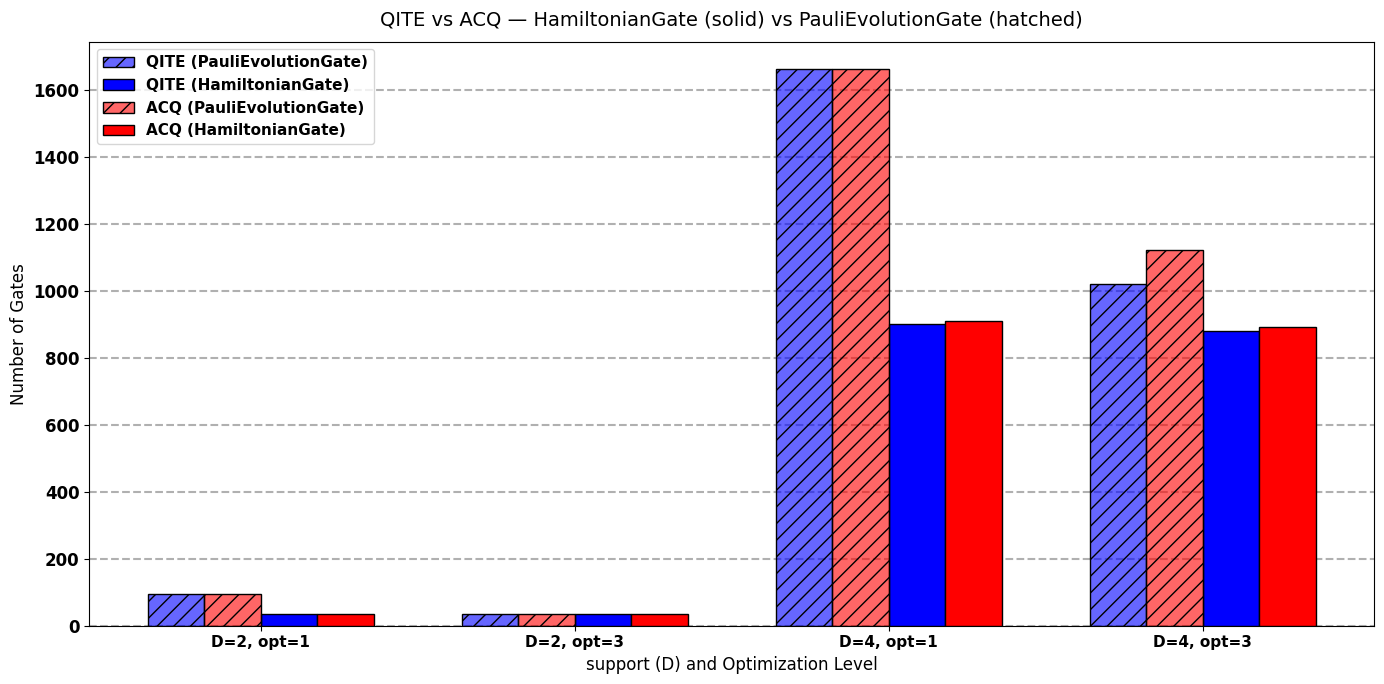

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_from_gate_counts_hatched(
    gate_counts, D_values, opt_levels,
    ylabel="Number of Gates",
    xlabel="support (D) and Optimization Level",
    title=None,
    figsize=(14, 7),
    barWidth=0.18,
):

    # Build groups: (D, opt)
    pairs = [(D, opt) for D in D_values for opt in opt_levels]
    x = np.arange(len(pairs))
    x_labels = [f"D={D}, opt={opt}" for D, opt in pairs]

    # Extract data
    qite_ham   = [gate_counts[D][opt]["QITE"]["Ham"]      for D, opt in pairs]
    qite_pauli = [gate_counts[D][opt]["QITE"]["Pauli"]    for D, opt in pairs]
    ada_ham    = [gate_counts[D][opt]["AdaQITE"]["Ham"]   for D, opt in pairs]
    ada_pauli  = [gate_counts[D][opt]["AdaQITE"]["Pauli"] for D, opt in pairs]

    # Bar positions (same logic as collaborator)
    br1 = x - 3/2 * barWidth
    br2 = x - 1/2 * barWidth
    br3 = x + 1/2 * barWidth
    br4 = x + 3/2 * barWidth

    fig, ax = plt.subplots(figsize=figsize)

    # --- QITE ---
    ax.bar(
        br1, qite_pauli,
        width=barWidth,
        color=(0, 0, 1, 0.6),      # transparent blue
        hatch='//',
        edgecolor='black',
        linewidth=1,
        zorder=3,
        label="QITE (PauliEvolutionGate)"
    )

    ax.bar(
        br3, qite_ham,
        width=barWidth,
        color='b',
        edgecolor='black',
        linewidth=1,
        zorder=3,
        label="QITE (HamiltonianGate)"
    )

    # --- ACQ ---
    ax.bar(
        br2, ada_pauli,
        width=barWidth,
        color=(1, 0, 0, 0.6),      # transparent red
        hatch='//',
        edgecolor='black',
        linewidth=1,
        zorder=3,
        label="ACQ (PauliEvolutionGate)"
    )

    ax.bar(
        br4, ada_ham,
        width=barWidth,
        color='r',
        edgecolor='black',
        linewidth=1,
        zorder=3,
        label="ACQ (HamiltonianGate)"
    )

    # Axes / grid styling
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.grid(axis='y', linestyle='--', linewidth=1.5, zorder=0)
    ax.set_axisbelow(True)

    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel(xlabel, fontsize=12)

    if title is None:
        title = "QITE vs ACQ — HamiltonianGate (solid) vs PauliEvolutionGate (hatched)"
    ax.set_title(title, fontsize=14, pad=12)

    ax.legend(fontsize=11, loc="upper left")

    plt.tight_layout()
    plt.show()

    return fig, ax


# Call it
fig, ax = plot_from_gate_counts_hatched(
    gate_counts, D_values, opt_levels
)

#fig.savefig(f"transpiled_gates_first_step_N{n_qubits}D{D}T{T}J{J}h{h}DEVGEN.pdf", dpi=300, bbox_inches='tight')
